In [2]:
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing_extensions import TypedDict

c:\Users\aksha\OneDrive\Desktop\langgraph\langgraph\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
load_dotenv()

True

In [10]:
class SubState(TypedDict):
    input_text :str
    translated_text : str
    
subgraph_llm = ChatGroq(model="qwen/qwen3.6-27b")

In [11]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

In [12]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [13]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str
    
parent_llm = ChatGroq(model="qwen/qwen3.6-27b")

def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

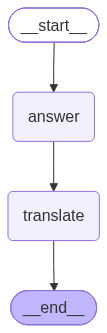

In [14]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

graph = parent_builder.compile()

graph

In [15]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': '\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - **Question:** "What is quantum physics"\n   - **Intent:** The user wants a clear, concise explanation of quantum physics.\n   - **Tone/Style:** Helpful, clear, accessible but accurate.\n\n2.  **Identify Key Concepts of Quantum Physics:**\n   - Definition: Branch of physics dealing with very small scales (atoms, subatomic particles).\n   - Core principles: Quantization, wave-particle duality, superposition, entanglement, uncertainty principle.\n   - Contrast with classical physics: Classical physics works for everyday/macroscopic objects; quantum physics governs the microscopic world.\n   - Applications: Computers, lasers, MRI, semiconductors, quantum computing, cryptography.\n   - Historical context: Early 20th century, developed by Planck, Einstein, Bohr, Heisenberg, Schrödinger, Dirac, etc.\n\n3.  **Structure the Response:**\n   - Clear definition upfron